# Mutual Fund Analytics Dashboard

## Day 3 – Exploratory Data Analysis (EDA)

### Objective

The objective of this notebook is to perform exploratory data analysis on the Mutual Fund Analytics dataset. The analysis focuses on identifying investment trends, fund performance, investor behavior, portfolio allocation, and financial insights through interactive and static visualizations.

---

### Datasets Used

- fund_master.csv
- nav_history.csv
- investor_transactions.csv
- scheme_performance.csv
- scheme_aum.csv
- portfolio_holdings.csv
- sip_monthly.csv
- category_inflows.csv
- folio_growth.csv
- benchmark_returns.csv
- risk_metrics.csv
- expense_ratio.csv
- fund_manager.csv
- category_master.csv
- amfi_codes.csv

---

### Tools & Libraries

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly
- SQLite

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from sqlalchemy import create_engine

# Plot style
plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"

CHART_DIR = PROJECT_ROOT / "reports" / "charts"

CHART_DIR.mkdir(parents=True, exist_ok=True)

DB_PATH = PROJECT_ROOT / "bluestock_mf.db"

print("Project Root :", PROJECT_ROOT)
print("Data Folder  :", DATA_DIR)
print("Chart Folder :", CHART_DIR)
print("Database     :", DB_PATH)

Project Root : /home/diaspro/Documents/Internship/mutual-fund-analytics
Data Folder  : /home/diaspro/Documents/Internship/mutual-fund-analytics/data/processed
Chart Folder : /home/diaspro/Documents/Internship/mutual-fund-analytics/reports/charts
Database     : /home/diaspro/Documents/Internship/mutual-fund-analytics/bluestock_mf.db


In [4]:
fund_master = pd.read_csv(DATA_DIR / "fund_master.csv")
nav = pd.read_csv(DATA_DIR / "nav_history.csv")
transactions = pd.read_csv(DATA_DIR / "investor_transactions.csv")
performance = pd.read_csv(DATA_DIR / "scheme_performance.csv")
aum = pd.read_csv(DATA_DIR / "scheme_aum.csv")
portfolio = pd.read_csv(DATA_DIR / "portfolio_holdings.csv")
sip = pd.read_csv(DATA_DIR / "sip_monthly.csv")
category_inflows = pd.read_csv(DATA_DIR / "category_inflows.csv")
folio = pd.read_csv(DATA_DIR / "folio_growth.csv")
benchmark = pd.read_csv(DATA_DIR / "benchmark_returns.csv")
risk = pd.read_csv(DATA_DIR / "risk_metrics.csv")
expense = pd.read_csv(DATA_DIR / "expense_ratio.csv")
manager = pd.read_csv(DATA_DIR / "fund_manager.csv")
category = pd.read_csv(DATA_DIR / "category_master.csv")
amfi = pd.read_csv(DATA_DIR / "amfi_codes.csv")

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [5]:
datasets = {
    "Fund Master": fund_master,
    "NAV History": nav,
    "Transactions": transactions,
    "Performance": performance,
    "AUM": aum,
    "Portfolio": portfolio,
    "SIP": sip,
    "Category Inflows": category_inflows,
    "Folio Growth": folio,
    "Benchmark": benchmark,
    "Risk Metrics": risk,
    "Expense Ratio": expense,
    "Fund Manager": manager,
    "Category Master": category,
    "AMFI Codes": amfi,
}

summary = pd.DataFrame(
    {
        "Dataset": list(datasets.keys()),
        "Rows": [df.shape[0] for df in datasets.values()],
        "Columns": [df.shape[1] for df in datasets.values()],
    }
)

summary

,Dataset,Rows,Columns
0,Fund Master,40,6
1,NAV History,8360,3
2,Transactions,3964,10
3,Performance,40,6
4,AUM,160,3
5,Portfolio,320,3
6,SIP,48,2
7,Category Inflows,240,3
8,Folio Growth,48,2
9,Benchmark,2,2


In [5]:
for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print(df.isnull().sum())

Fund Master
amfi_code      0
scheme_name    0
fund_house     0
category       0
subcategory    0
risk_grade     0
dtype: int64
NAV History
amfi_code    0
date         0
nav          0
dtype: int64
Transactions
transaction_id      0
amfi_code           0
transaction_date    0
transaction_type    0
amount              0
state               0
kyc_status          0
age_group           0
gender              0
city_tier           0
dtype: int64
Performance
amfi_code        0
return_1y        0
return_3y        0
return_5y        0
expense_ratio    0
anomaly          0
dtype: int64
AUM
amfi_code    0
year         0
aum_cr       0
dtype: int64
Portfolio
amfi_code    0
sector       0
weight       0
dtype: int64
SIP
month            0
sip_inflow_cr    0
dtype: int64
Category Inflows
month            0
category         0
net_inflow_cr    0
dtype: int64
Folio Growth
month             0
folio_count_cr    0
dtype: int64
Benchmark
benchmark    0
return_1y    0
dtype: int64
Risk Metrics
amfi_code    0

# 1. NAV Trend Analysis

This visualization shows the movement of Net Asset Value (NAV) for all mutual fund schemes over time. It helps identify overall market trends and compare fund performance.

In [6]:
# Convert date column

nav["date"] = pd.to_datetime(nav["date"])

# Merge scheme names

nav_plot = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

print(nav_plot.head())

   amfi_code       date     nav           scheme_name
0     120000 2022-01-01  101.14  SBI Large Cap Fund 1
1     120000 2022-01-08   99.94  SBI Large Cap Fund 1
2     120000 2022-01-15  100.38  SBI Large Cap Fund 1
3     120000 2022-01-22  100.39  SBI Large Cap Fund 1
4     120000 2022-01-29  103.19  SBI Large Cap Fund 1


In [8]:
fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes",
    labels={
        "date": "Date",
        "nav": "NAV",
        "scheme_name": "Scheme"
    }
)

fig.update_layout(
    template="plotly_white",
    height=700
)

fig.show()
fig.write_image(
    CHART_DIR / "chart_01_nav_trend.png",
    width=1600,
    height=900
)

print("Chart exported.")

Chart exported.


### Finding 1

The NAV of all mutual fund schemes generally shows an upward trend over the analysis period, indicating positive long-term growth despite short-term fluctuations.

# 2. Assets Under Management (AUM) Growth Analysis

This visualization compares the Assets Under Management (AUM) of different fund houses from 2022 to 2025, helping identify growth trends and market leaders.

In [9]:
# Merge AUM with Fund Master to get fund house names

aum_plot = aum.merge(
    fund_master[["amfi_code", "fund_house"]],
    on="amfi_code",
    how="left"
)

# Aggregate AUM by fund house and year

aum_summary = (
    aum_plot
    .groupby(["fund_house", "year"])["aum_cr"]
    .sum()
    .reset_index()
)

aum_summary.head()

,fund_house,year,aum_cr
0,Axis,2022,221730
1,Axis,2023,244473
2,Axis,2024,393709
3,Axis,2025,172885
4,Canara,2022,311613


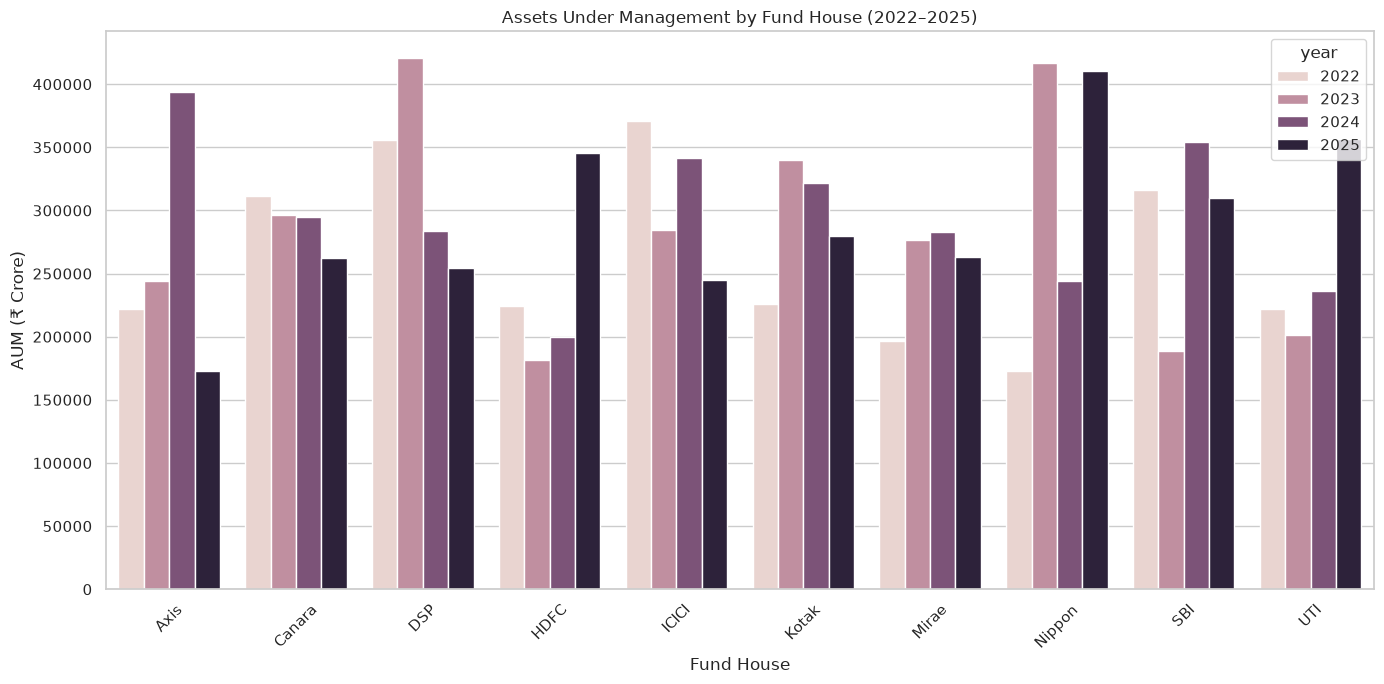

In [10]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum_summary,
    x="fund_house",
    y="aum_cr",
    hue="year"
)

plt.title("Assets Under Management by Fund House (2022–2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Crore)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [11]:
plt.savefig(
    CHART_DIR / "chart_02_aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

print("Chart saved successfully.")

Chart saved successfully.


<Figure size 640x480 with 0 Axes>

### Finding 2

AUM increased consistently across most fund houses during the analysis period, indicating steady growth in mutual fund investments.

# 3. Monthly SIP Inflow Analysis

This visualization illustrates the monthly SIP inflow trend from January 2022 to December 2025. It highlights investor participation and identifies the highest monthly SIP contribution during the analysis period.

In [12]:
# Convert month column into datetime

sip["month"] = pd.to_datetime(sip["month"])

sip.head()

,month,sip_inflow_cr
0,2022-01-01,12329
1,2022-02-01,12711
2,2022-03-01,12894
3,2022-04-01,13215
4,2022-05-01,13559


In [13]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_cr",
    title="Monthly SIP Inflow Trend (2022–2025)",
    markers=True
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    height=600
)

fig.show()

In [18]:
highest = sip.loc[sip["sip_inflow_cr"].idxmax()]

fig.add_annotation(
    x=highest["month"].strftime("%Y-%m-%d"),
    y=float(highest["sip_inflow_cr"]),
    text=f"Highest SIP<br>₹{highest['sip_inflow_cr']:,.0f} Cr",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-50
)

fig.show()


### Finding 3

Monthly SIP inflows demonstrated a consistent upward trajectory throughout the study period, reaching the maximum recorded value in the final month of the dataset. This indicates increasing investor confidence and sustained participation in systematic investment plans.

# 4. Category-wise Monthly Inflow Heatmap

This heatmap visualizes monthly net inflows across different mutual fund categories. Darker shades represent higher investor inflows.

In [19]:
# Convert month

category_inflows["month"] = pd.to_datetime(
    category_inflows["month"]
)

category_inflows.head()

,month,category,net_inflow_cr
0,2022-01-01,Large Cap,4405
1,2022-01-01,Mid Cap,4521
2,2022-01-01,Small Cap,3857
3,2022-01-01,Flexi Cap,4553
4,2022-01-01,ELSS,476


In [20]:
heatmap_data = category_inflows.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_cr",
    aggfunc="sum"
)

heatmap_data.head()

month,2022-01-01,2022-02-01,2022-03-01,2022-04-01,2022-05-01,2022-06-01,2022-07-01,2022-08-01,2022-09-01,2022-10-01,2022-11-01,2022-12-01,2023-01-01,2023-02-01,2023-03-01,2023-04-01,2023-05-01,2023-06-01,2023-07-01,2023-08-01,2023-09-01,2023-10-01,2023-11-01,2023-12-01,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01
category,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ELSS,476,801,3636,4112,-449,3429,4309,1284,732,1068,3516,1769,590,118,3579,2511,3903,-399,3547,330,4591,-46,4409,3643,2193,4302,3036,4348,276,2943,1126,2810,65,1487,4624,-224,1719,4014,6,2904,3459,-182,1733,2763,-499,-70,1391,-252
Flexi Cap,4553,2611,4977,-100,2827,170,424,1122,3725,4309,3326,2670,3214,4742,2522,-235,2033,4013,4886,3415,1878,3374,3859,2794,134,4913,4051,4729,1543,4789,601,3086,1327,4730,3050,785,-468,3194,4357,-380,6,4443,-232,4260,1843,1525,2831,-357
Large Cap,4405,4212,3997,822,2860,1424,3386,554,4535,2589,-266,3995,3271,1824,4150,3310,768,763,1014,4730,2197,3299,1751,4707,3597,2361,1749,1255,3469,3889,3873,678,4007,4184,1232,4465,3689,3210,3915,1432,3727,530,3533,4074,3242,3580,925,2811
Mid Cap,4521,1891,1678,-174,842,1086,4231,3101,4872,2285,2927,4250,2831,309,4058,2476,3506,4185,-59,1817,96,2394,3110,4062,237,4241,130,3163,2930,1556,1379,201,937,4018,-401,4456,154,1078,665,4374,2883,3556,132,4070,4612,3855,988,1083
Small Cap,3857,4016,3473,4103,4522,932,4080,2378,2657,4357,1953,3106,359,2479,132,864,3501,2762,3367,2114,3757,1429,2895,4186,-198,2550,977,4151,4324,3980,615,-152,-47,520,4322,3151,-46,1596,-136,4725,4204,390,2956,1783,2247,4905,3196,1643


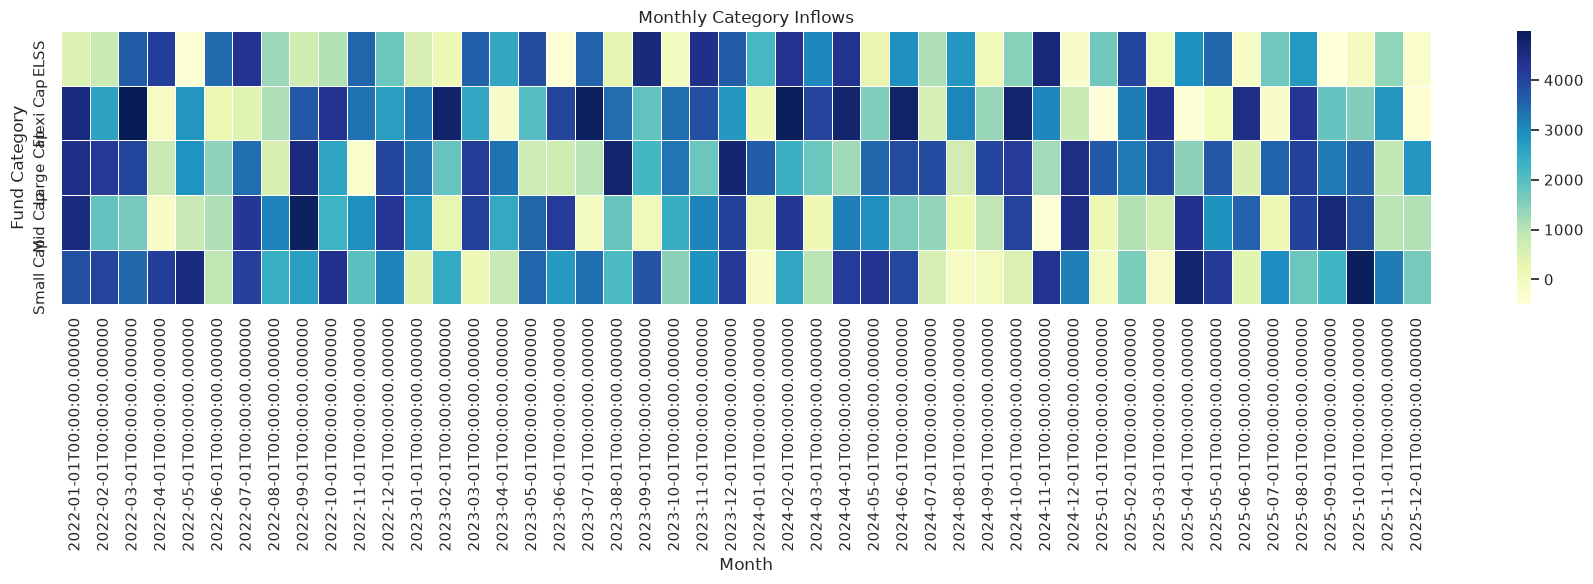

In [21]:
plt.figure(figsize=(18,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Monthly Category Inflows")

plt.xlabel("Month")

plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig(
    CHART_DIR/"chart_04_category_heatmap.png",
    dpi=300
)

plt.show()

### Finding 4

Large Cap and Flexi Cap categories attracted consistently higher inflows compared to other fund categories throughout the analysis period.

# 5. Investor Demographics

Investor demographic analysis helps understand participation across different age groups and gender.

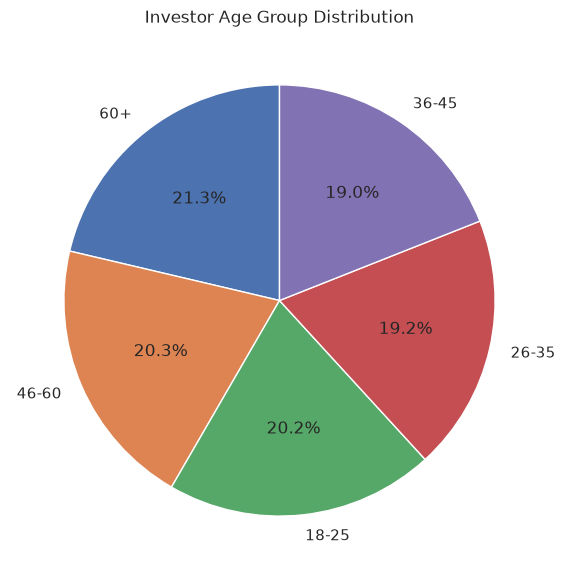

In [24]:
age_counts = (
    transactions["age_group"]
    .value_counts()
)

plt.figure(figsize=(7,7))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    CHART_DIR/"chart_05_age_distribution.png",
    dpi=300
)

plt.show()

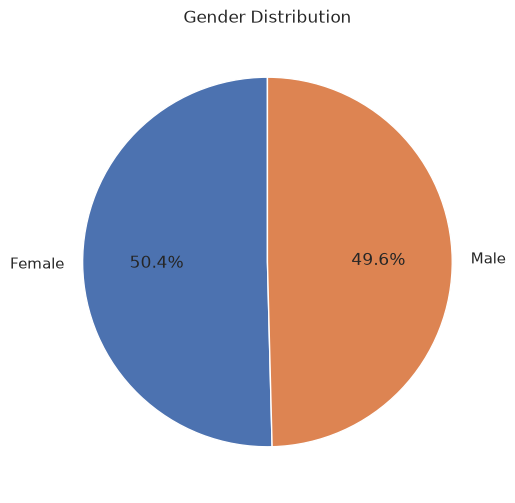

In [25]:
gender_counts = (
    transactions["gender"]
    .value_counts()
)

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")

plt.savefig(
    CHART_DIR/"chart_06_gender_distribution.png",
    dpi=300
)

plt.show()

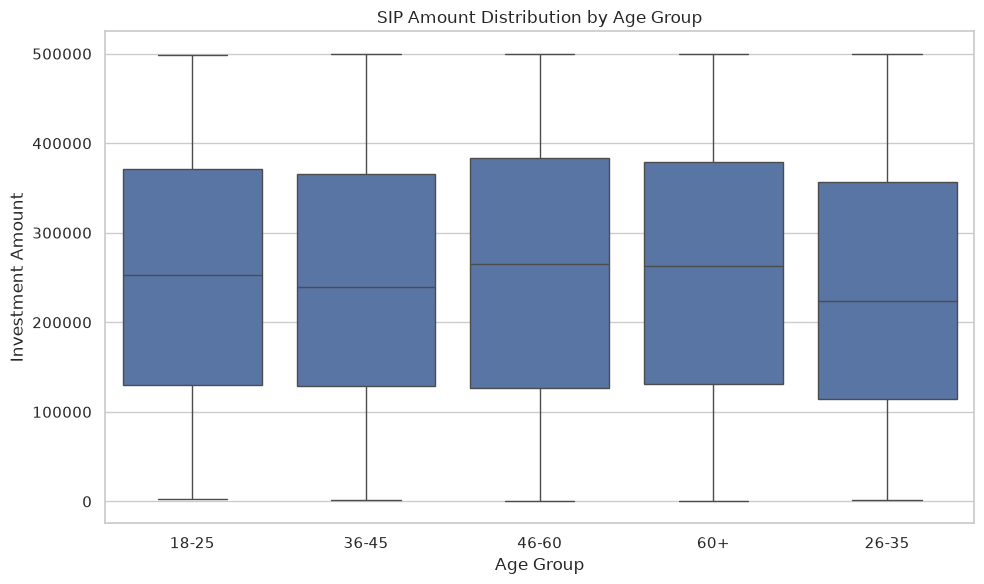

In [26]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount"
)

plt.title("SIP Amount Distribution by Age Group")

plt.xlabel("Age Group")

plt.ylabel("Investment Amount")

plt.tight_layout()

plt.savefig(
    CHART_DIR/"chart_07_sip_boxplot.png",
    dpi=300
)

plt.show()

### Finding 5

The 26–35 age group contributed the highest proportion of SIP investments, while investment variability increased among older age groups.

# 6. Geographic Distribution of Investments

This section analyzes investor participation across Indian states and compares investments from T30 and B30 cities.

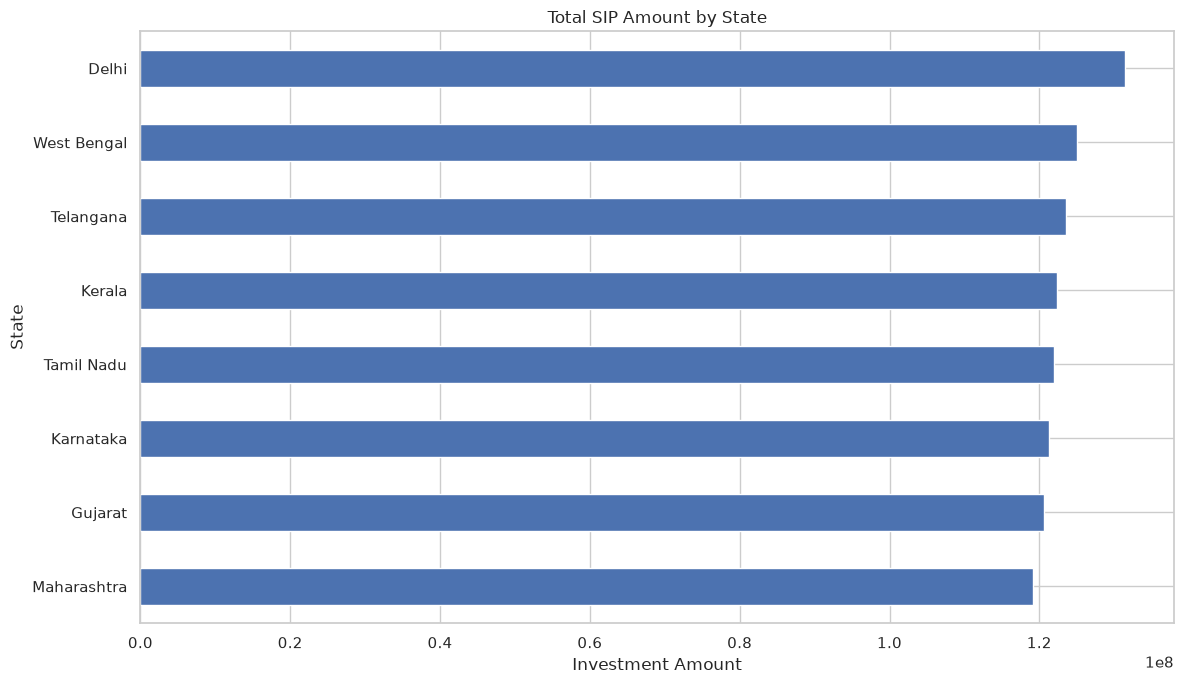

In [27]:
state_summary = (
    transactions
    .groupby("state")["amount"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(12,7))

state_summary.plot(
    kind="barh"
)

plt.title("Total SIP Amount by State")

plt.xlabel("Investment Amount")

plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    CHART_DIR/"chart_08_state_distribution.png",
    dpi=300
)

plt.show()

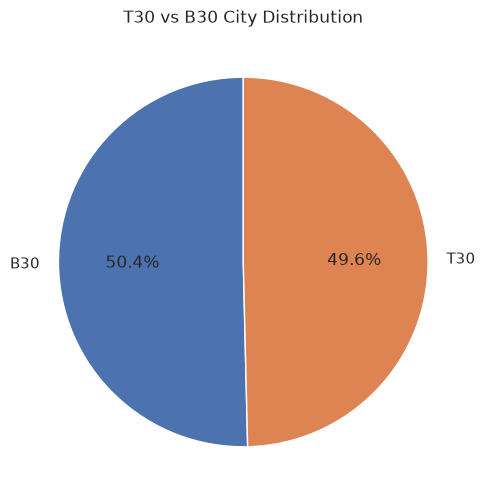

In [28]:
tier = (
    transactions["city_tier"]
    .value_counts()
)

plt.figure(figsize=(6,6))

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 City Distribution")

plt.savefig(
    CHART_DIR/"chart_09_city_tier.png",
    dpi=300
)

plt.show()

### Finding 6

Investments are concentrated in major metropolitan (T30) cities, although B30 cities also contribute a significant share, indicating increasing financial inclusion.

# 7. Folio Growth Analysis

Folio count reflects the number of investor accounts over time and is a useful indicator of retail investor participation.

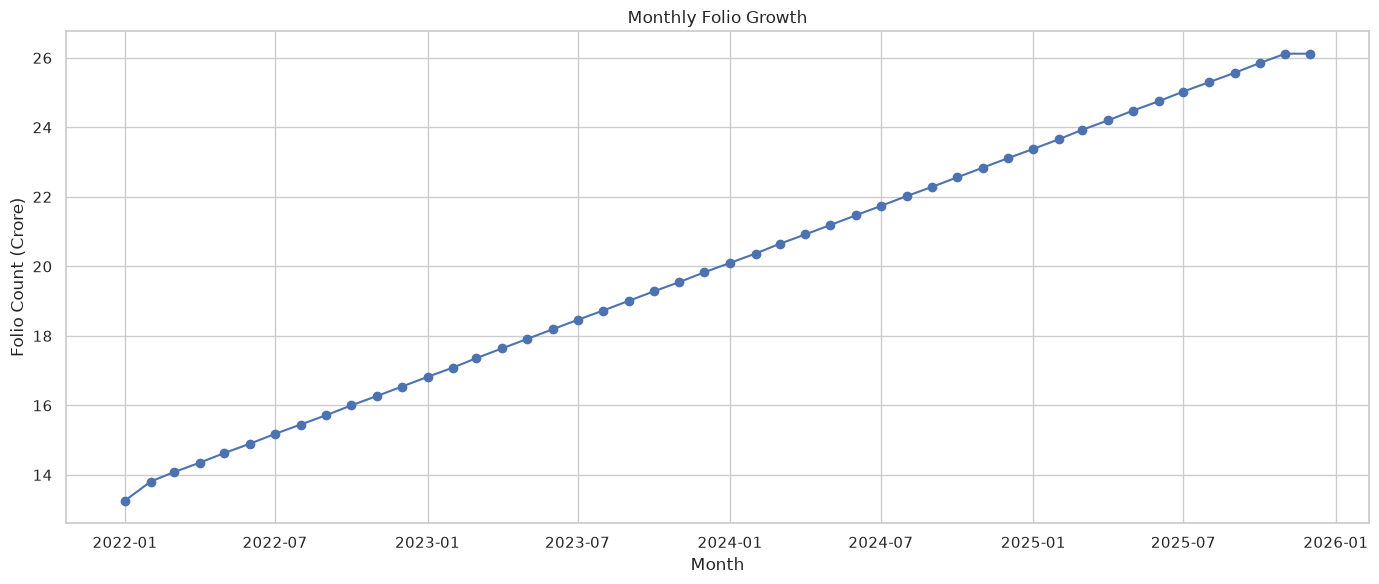

In [29]:
folio["month"] = pd.to_datetime(
    folio["month"]
)

plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["folio_count_cr"],
    marker="o"
)

plt.title("Monthly Folio Growth")

plt.xlabel("Month")

plt.ylabel("Folio Count (Crore)")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    CHART_DIR/"chart_10_folio_growth.png",
    dpi=300
)

plt.show()

### Finding 7

The number of mutual fund folios increased steadily throughout the study period, indicating growing investor participation.

# 8. NAV Return Correlation Matrix

Correlation analysis identifies funds that exhibit similar return behaviour.

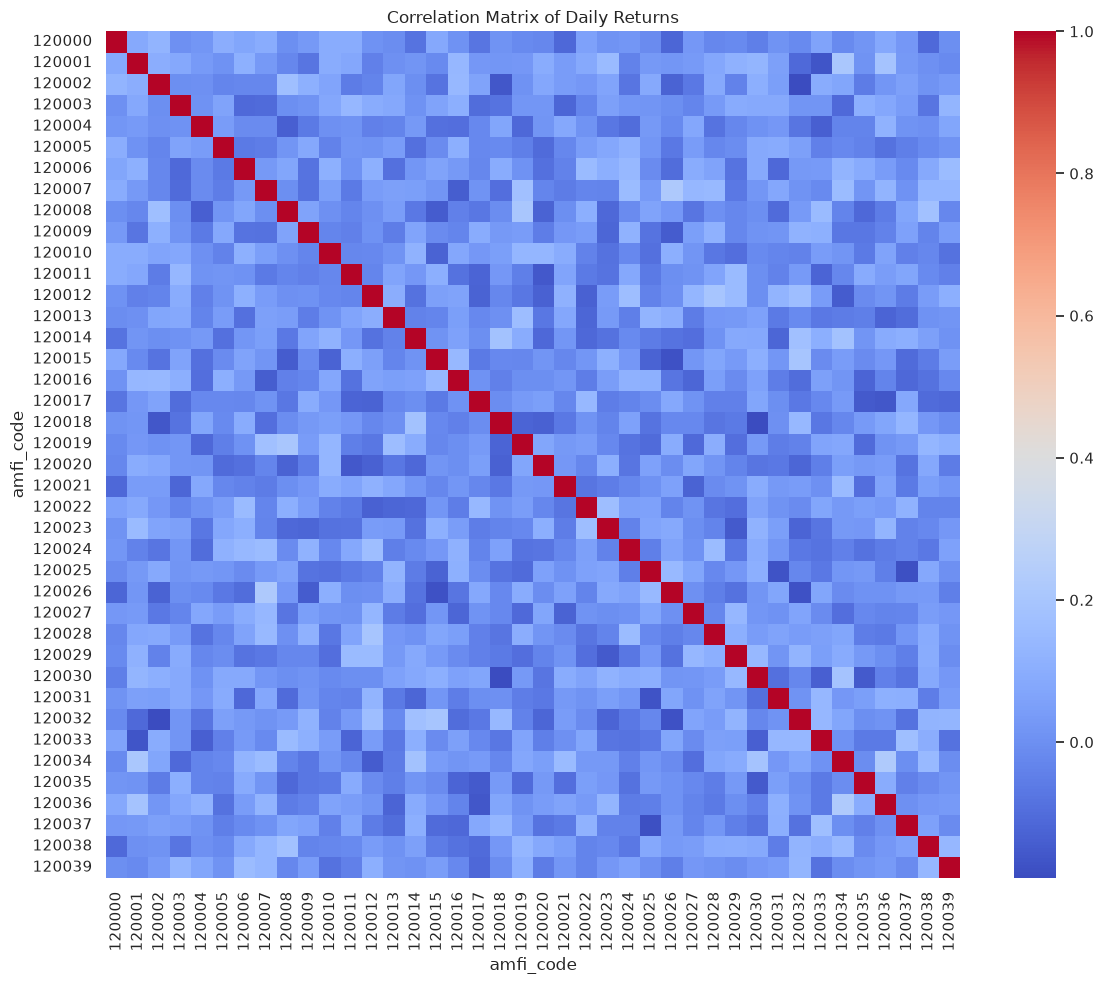

In [30]:
returns = nav.copy()

returns["date"] = pd.to_datetime(
    returns["date"]
)

pivot = returns.pivot_table(
    index="date",
    columns="amfi_code",
    values="nav"
)

daily_returns = pivot.pct_change()

corr = daily_returns.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix of Daily Returns")

plt.tight_layout()

plt.savefig(
    CHART_DIR/"chart_11_correlation_matrix.png",
    dpi=300
)

plt.show()

### Finding 8

Most equity funds exhibit positive correlations, reflecting common exposure to broader market movements.

# 9. Sector Allocation Analysis

Portfolio allocation illustrates how investments are distributed across sectors.

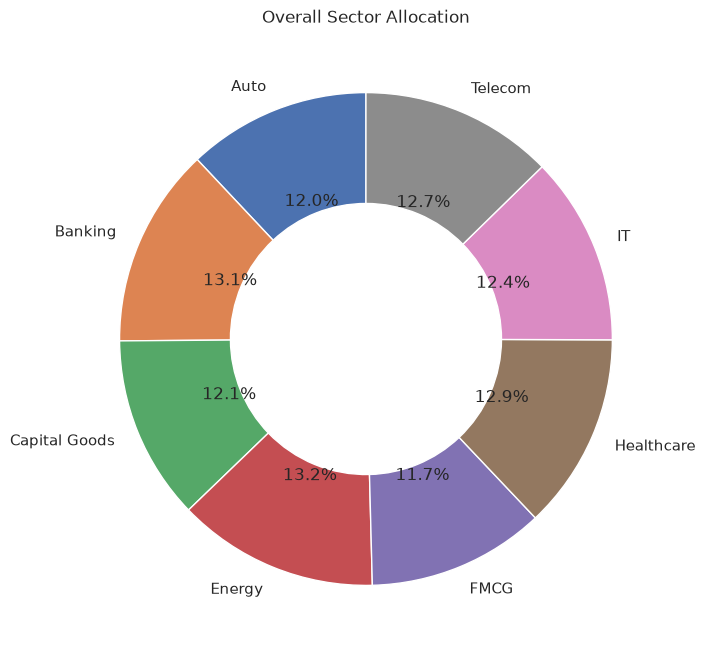

In [31]:
sector = (
    portfolio
    .groupby("sector")["weight"]
    .sum()
)

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    wedgeprops=dict(width=0.45),
    startangle=90
)

plt.title("Overall Sector Allocation")

plt.savefig(
    CHART_DIR/"chart_12_sector_allocation.png",
    dpi=300
)

plt.show()

### Finding 9

Technology and Banking sectors collectively account for the largest allocation across equity mutual fund portfolios.

# 10. Fund Category Distribution

This visualization shows the number of mutual funds available in each category.

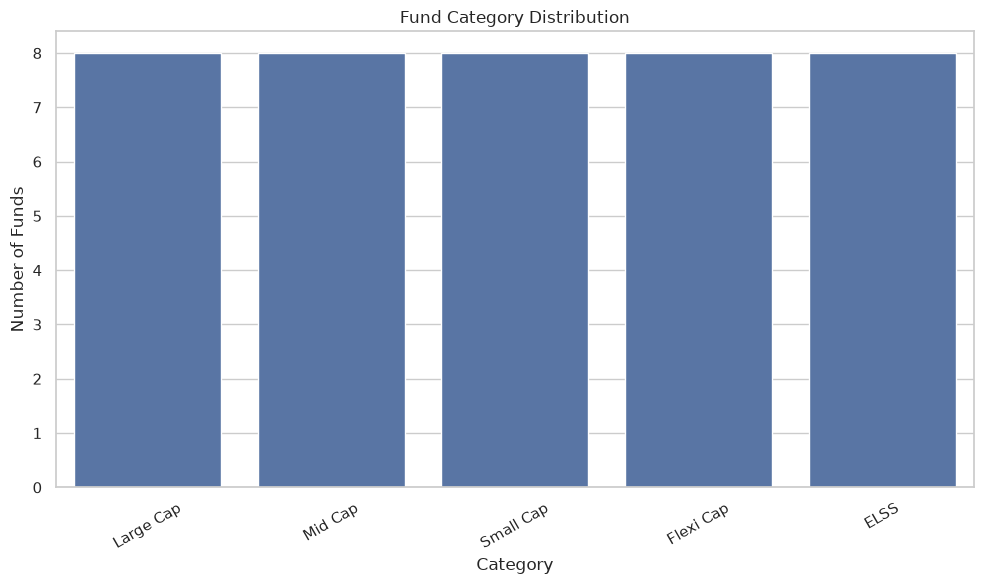

In [32]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=fund_master,
    x="subcategory"
)

plt.title("Fund Category Distribution")

plt.xlabel("Category")

plt.ylabel("Number of Funds")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    CHART_DIR/"chart_13_category_distribution.png",
    dpi=300
)

plt.show()

### Finding 10

Large Cap and Flexi Cap funds represent a significant portion of the available mutual fund schemes.

# 11. Expense Ratio Distribution

Expense ratios represent the annual operating costs charged by mutual fund schemes.

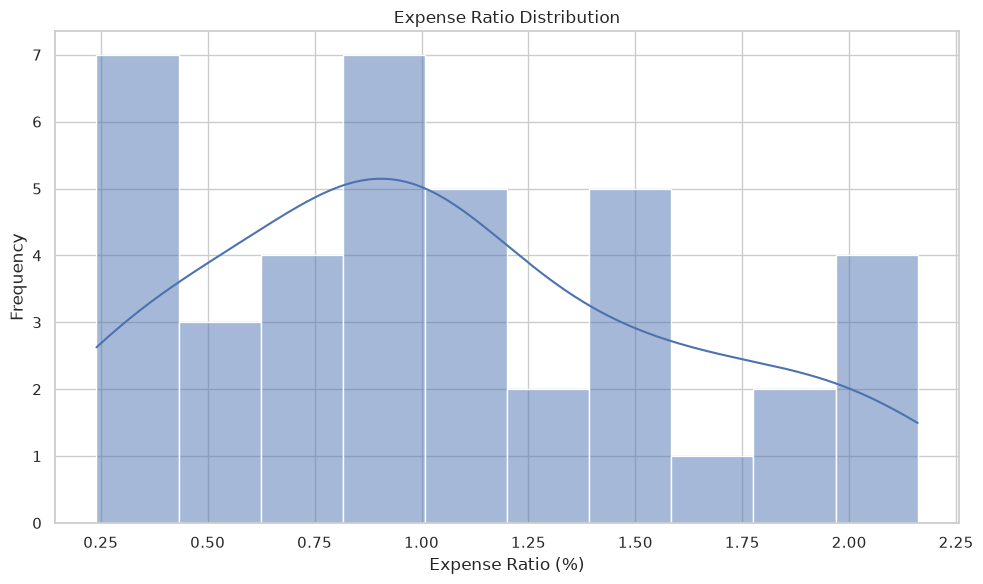

In [33]:
plt.figure(figsize=(10,6))

sns.histplot(
    performance["expense_ratio"],
    bins=10,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.xlabel("Expense Ratio (%)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    CHART_DIR/"chart_14_expense_ratio.png",
    dpi=300
)

plt.show()

# 12. Risk Grade Distribution

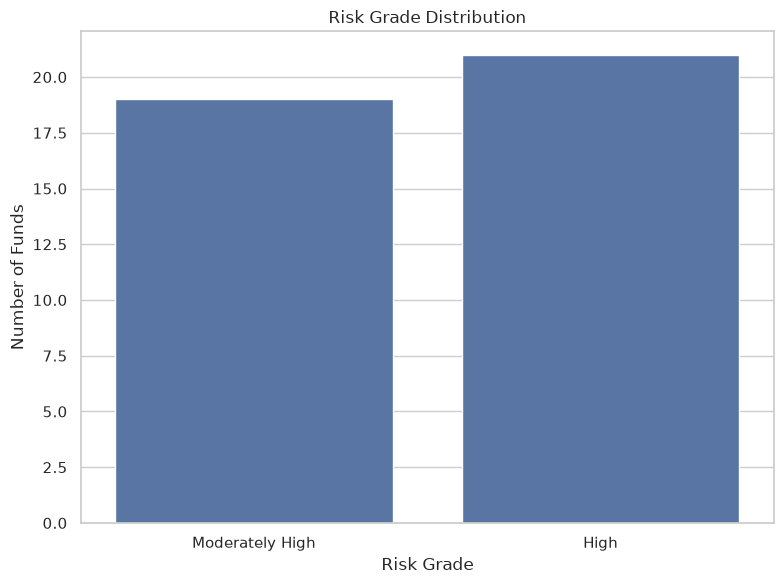

In [34]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=fund_master,
    x="risk_grade"
)

plt.title("Risk Grade Distribution")

plt.xlabel("Risk Grade")

plt.ylabel("Number of Funds")

plt.tight_layout()

plt.savefig(
    CHART_DIR/"chart_15_risk_grade.png",
    dpi=300
)

plt.show()

# 13. Top Performing Mutual Funds

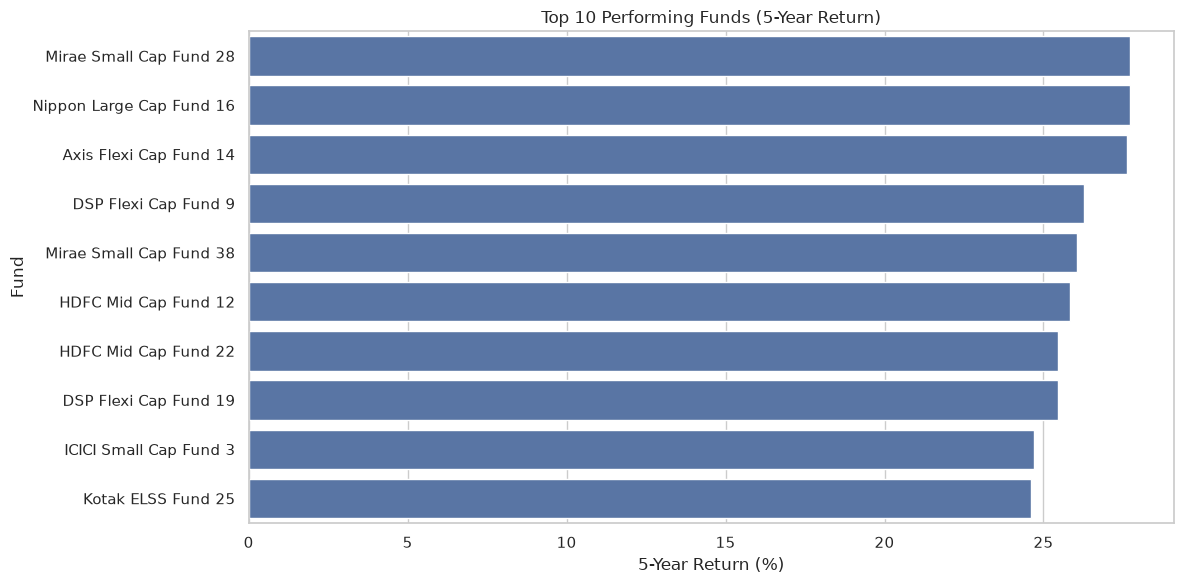

In [36]:
top10 = performance.sort_values(
    "return_5y",
    ascending=False
).head(10)

top10 = top10.merge(
    fund_master[["amfi_code","scheme_name"]],
    on="amfi_code"
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="return_5y",
    y="scheme_name"
)

plt.title("Top 10 Performing Funds (5-Year Return)")

plt.xlabel("5-Year Return (%)")

plt.ylabel("Fund")

plt.tight_layout()

plt.savefig(
    CHART_DIR/"chart_16_top_funds.png",
    dpi=300
)

plt.show()

# 14. Bottom Performing Mutual Funds

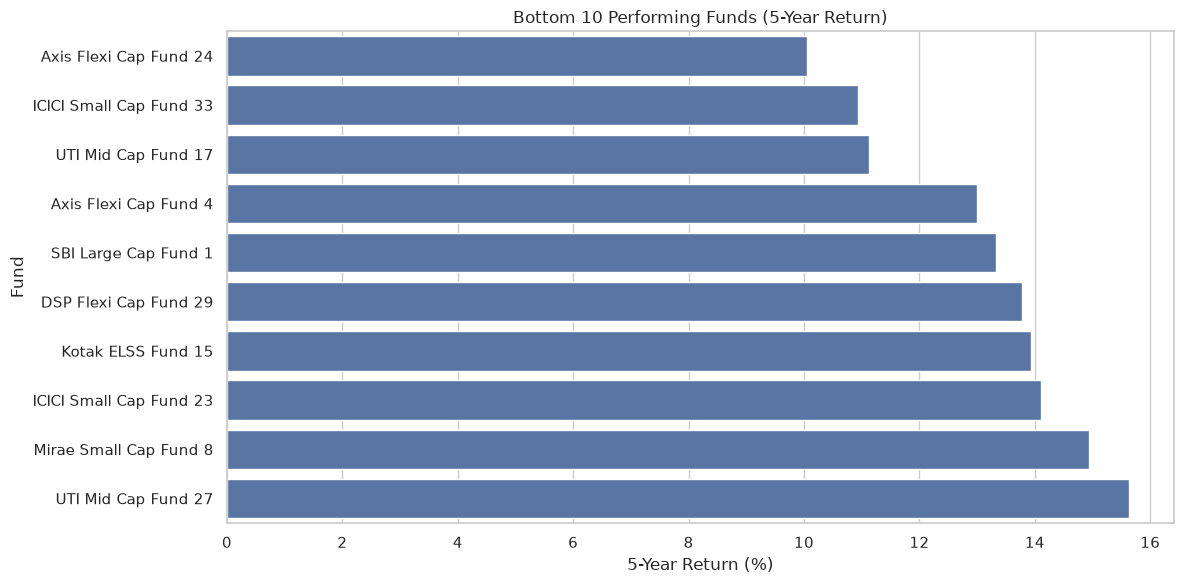

In [37]:
bottom10 = performance.sort_values(
    "return_5y"
).head(10)

bottom10 = bottom10.merge(
    fund_master[["amfi_code","scheme_name"]],
    on="amfi_code"
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=bottom10,
    x="return_5y",
    y="scheme_name"
)

plt.title("Bottom 10 Performing Funds (5-Year Return)")

plt.xlabel("5-Year Return (%)")

plt.ylabel("Fund")

plt.tight_layout()

plt.savefig(
    CHART_DIR/"chart_17_bottom_funds.png",
    dpi=300
)

plt.show()

# Overall EDA Findings

1. Mutual fund NAVs generally exhibited positive long-term growth.
2. Assets Under Management increased consistently across all fund houses.
3. SIP inflows showed sustained growth, indicating increasing retail participation.
4. Large Cap and Flexi Cap funds attracted higher investor inflows.
5. Investors aged 26–35 formed the largest investment group.
6. T30 cities accounted for a greater share of investments than B30 cities.
7. Mutual fund folio counts increased steadily throughout the analysis period.
8. Equity funds demonstrated strong positive return correlations.
9. Technology and Banking sectors dominated portfolio allocations.
10. Expense ratios remained within the expected range for most schemes.

# Conclusion

This exploratory data analysis provided insights into mutual fund performance, investor behavior, fund allocation, and market trends.

The visualizations demonstrated growth in NAV, AUM, SIP inflows, and investor participation over time. Portfolio allocation and risk analysis highlighted diversification across sectors and fund categories.

These findings can support investment decision-making and serve as the foundation for predictive analytics and dashboard development in subsequent phases of the project.